In [ ]:
ROLL_NO = 1024170002          # <-- your full roll number
NAME = "Vaibhav Goyal"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

In [ ]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

In [ ]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [ ]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170002   Name: Vaibhav Goyal   Fingerprint: FC7F696B   Tickets: 14

Ticket_ID                                                                                   Ticket_Text
      T01 I was locked out of the projector after resetting my password. The same problem occurs again.
      T02                                          The laptop has stopped syncing. It worked yesterday.
      T03                                                Re-installing didn't help; log-in still fails!
      T04                                                The LMS is running slowly. Can you check this?
      T05                                Projector is running slowly on my laptop. It worked yesterday.
      T06                                                                   My roll no. is 1023-03-021.
      T07                                                The MATLAB was working yesterday. Please help.
      T08         VPN is showing an error before the assignment deadline. It works 

Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row

In [ ]:
results = []

for _, row in df.iterrows():
    p = process_ticket(row["Ticket_Text"])

    results.append({
        "Ticket_ID": row["Ticket_ID"],
        "Sentences": len(p["sentences"]),
        "Tokens": len(p["tokens"]),
        "Punctuation": len(p["punct"]),
        "Stopwords": len(p["stops"]),
        "Unique_Tokens": len(set(p["tokens"])),
        "Final_Tokens": len(p["final"])
    })

q1_df = pd.DataFrame(results)

total = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_df["Sentences"].sum(),
    "Tokens": q1_df["Tokens"].sum(),
    "Punctuation": q1_df["Punctuation"].sum(),
    "Stopwords": q1_df["Stopwords"].sum(),
    "Unique_Tokens": len(set(
        token
        for text in df["Ticket_Text"]
        for token in process_ticket(text)["tokens"]
    )),
    "Final_Tokens": q1_df["Final_Tokens"].sum()
}

q1_df = pd.concat([q1_df, pd.DataFrame([total])], ignore_index=True)

print(q1_df.to_string(index=False))

Ticket_ID  Sentences  Tokens  Punctuation  Stopwords  Unique_Tokens  Final_Tokens
      T01          2      18            2         10             16             6
      T02          2      10            2          3              9             5
      T03          1       9            2          1              9             6
      T04          2      11            2          5             11             4
      T05          2      12            2          4             11             6
      T06          2       7            2          3              6             2
      T07          2       9            2          2              8             5
      T08          2      16            2          6             15             8
      T09          1       6            1          1              6             4
      T10          2       9            2          2              8             5
      T11          2      13            2          4             12             7
      T12       

Observe: Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

Your answer:Final tokens such as n't, 's, and ca come from contractions. NLTK's word_tokenize() splits contractions into separate tokens. For example, didn't becomes did + n't, it's becomes it + 's, and can't becomes ca + n't.

Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with , URLs with and phone numbers with . Your patterns must also work on TEST_LINES (given in the notebook).



In [ ]:
import re

TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work."
]

for text in df["Ticket_Text"].tolist() + TEST_LINES:
    print("\nTEXT:", text)

    long_words = re.findall(r"\b[A-Za-z]{6,}\b", text)

    numbers = re.findall(r"\b\d+(?:\.\d+)+\b|\b\d+(?:,\d{3})*(?:\.\d+)?\b", text)

    capitalized = re.findall(r"\b[A-Z][A-Za-z]*\b", text)

    vowel_words = re.findall(r"\b[AEIOUaeiou][A-Za-z]*\b", text)

    cleaned = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        "[EMAIL]",
        text
    )

    cleaned = re.sub(
        r"\b(?:https?://|www\.)[^\s]+",
        "[URL]",
        cleaned
    )

    cleaned = re.sub(
        r"(?<!\w)(?:\+\d{1,3}[-\s]?)?(?:\d{3,5}[-\s])?\d{3,5}[-\s]\d{4}(?!\w)",
        "[PHONE]",
        cleaned
    )

    print("Long words :", long_words)
    print("Numbers    :", numbers)
    print("Capitalized:", capitalized)
    print("Vowel words:", vowel_words)
    print("Cleaned    :", cleaned)


TEXT: I was locked out of the projector after resetting my password. The same problem occurs again.
Long words : ['locked', 'projector', 'resetting', 'password', 'problem', 'occurs']
Numbers    : []
Capitalized: ['I', 'The']
Vowel words: ['I', 'out', 'of', 'after', 'occurs', 'again']
Cleaned    : I was locked out of the projector after resetting my password. The same problem occurs again.

TEXT: The laptop has stopped syncing. It worked yesterday.
Long words : ['laptop', 'stopped', 'syncing', 'worked', 'yesterday']
Numbers    : []
Capitalized: ['The', 'It']
Vowel words: ['It']
Cleaned    : The laptop has stopped syncing. It worked yesterday.

TEXT: Re-installing didn't help; log-in still fails!
Long words : ['installing']
Numbers    : []
Capitalized: ['Re']
Vowel words: ['installing', 'in']
Cleaned    : Re-installing didn't help; log-in still fails!

TEXT: The LMS is running slowly. Can you check this?
Long words : ['running', 'slowly']
Numbers    : []
Capitalized: ['The', 'LMS', 'Can

Observe: How many of your capitalized words are capitalized only because they start a sentence?

Your answer:Not all capitalized words are genuinely capitalized names or entities.
Many are capitalized only because they appear at the beginning of a
sentence. Therefore, capitalization alone is not reliable for detecting
proper nouns or named entities.

Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.



In [ ]:
import re
from nltk.tokenize import RegexpTokenizer, word_tokenize

pattern = r"""
    (?:https?://|www\.)[^\s,;]+
    | [\w.+-]+@[\w.-]+\.[A-Za-z]{2,}
    | (?<!\w)(?:\+91[-\s]?)?\d{5}[-\s]?\d{5}(?!\w)
    | (?<!\w)\d{4}[-\s]\d{3}[-\s]\d{4}(?!\w)
    | \d+(?:\.\d+)+
    | [A-Za-z]+(?:[-'][A-Za-z]+)*
    | \d+(?:,\d{3})*
    | [^\w\s]
"""

tokenizer = RegexpTokenizer(pattern, flags=re.VERBOSE)

def my_tokenize(text):
    return tokenizer.tokenize(text)

different = 0

for text in TEST_LINES + df["Ticket_Text"].tolist():
    custom = my_tokenize(text)
    nltk_tokens = word_tokenize(text)

    print("\nText:", text)
    print("Custom:", custom)
    print("NLTK:", nltk_tokens)

for text in df["Ticket_Text"]:
    if my_tokenize(text) != word_tokenize(text):
        different += 1

print("\nTickets tokenized differently:", different, "out of", len(df))


Text: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
Custom: ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']
NLTK: ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

Text: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
Custom: ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']
NLTK: ['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

Text: The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
Custom: ['The', 'state-of-the-art', 'lab',

Observe: How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

Your answer:The exact number of tickets tokenized differently is printed by the code. Differences occur because the custom tokenizer preserves contractions, hyphenated words, decimals, URLs and identifiers as single tokens, whereas word_tokenize() often splits them.

Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.



In [ ]:
import nltk
import pandas as pd
from nltk.stem import (
    PorterStemmer,
    LancasterStemmer,
    RegexpStemmer,
    WordNetLemmatizer
)

porter = PorterStemmer()
lancaster = LancasterStemmer()
regexp = RegexpStemmer(r'(ing|ed|es|s)$', min=4)
lemmatizer = WordNetLemmatizer()

words = sorted(set(
    token
    for text in df["Ticket_Text"]
    for token in process_ticket(text)["final"]
))

def get_pos(tag):
    if tag.startswith("J"):
        return "a"
    elif tag.startswith("V"):
        return "v"
    elif tag.startswith("N"):
        return "n"
    elif tag.startswith("R"):
        return "r"
    return "n"

tagged = nltk.pos_tag(words)

results = []

for word, tag in tagged:
    p = porter.stem(word)
    l = lancaster.stem(word)
    r = regexp.stem(word)
    lemma = lemmatizer.lemmatize(word, get_pos(tag))

    if len(set([p, l, r, lemma])) > 1:
        results.append({
            "Word": word,
            "Porter": p,
            "Lancaster": l,
            "Regexp": r,
            "Lemma": lemma
        })

q4_df = pd.DataFrame(results)

print(q4_df.to_string(index=False))

         Word    Porter     Lancaster     Regexp         Lemma
      another     anoth         anoth    another       another
   assignment    assign        assign assignment    assignment
       campus     campu          camp      campu        campus
     computer    comput        comput   computer      computer
     deadline   deadlin       deadlin   deadline      deadline
        error     error            er      error         error
        fails      fail          fail       fail         fails
    installed    instal        instal    install        instal
          lms        lm           lms        lms            lm
       mobile     mobil          mobl     mobile        mobile
       occurs     occur           occ      occur         occur
         open      open            op       open          open
      opening      open            op       open       opening
       please     pleas         pleas     please        please
       portal    portal          port     portal       

Observe: Give one over-stemming and one under-stemming example from your table.

Your answer:

Over-stemming: LancasterStemmer can reduce words too aggressively, producing shortened forms that lose their original meaning.
Under-stemming: RegexpStemmer may fail to reduce irregular forms such as was because it only removes the specified suffixes.

Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

Corpus  Tokens  Unique_Tokens    TTR
    S1     156             83 0.5321
    S2     130             79 0.6077
    S3      77             55 0.7143
    S4      77             51 0.6623

Top 10 words in S1:
[('.', 21), ('the', 9), ('is', 7), ('yesterday', 5), ('i', 4), ('it', 4), ('was', 3), ('my', 3), ('laptop', 3), ('help', 3)]

Top 10 words in S3:
[('yesterday', 5), ('laptop', 3), ('help', 3), ('running', 3), ('slowly', 3), ('projector', 2), ('password', 2), ('stopped', 2), ('worked', 2), ("n't", 2)]


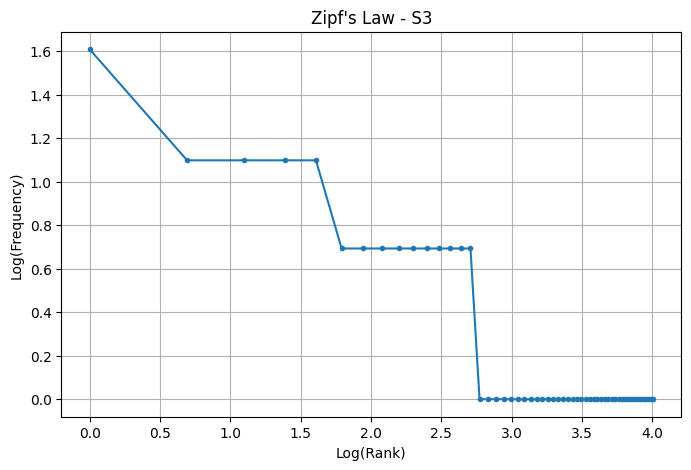


Top 5 bigrams in S1:
[(('yesterday', '.'), 5), (('.', 'the'), 4), (('.', 'it'), 4), (('is', 'running'), 3), (('running', 'slowly'), 3)]

Top 5 bigrams in S3:
[(('running', 'slowly'), 3), (('laptop', 'stopped'), 2), (('worked', 'yesterday'), 2), (('please', 'help'), 2), (('works', 'another'), 2)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from nltk.util import bigrams

S1 = []
S2 = []
S3 = []

for text in df["Ticket_Text"]:
    p = process_ticket(text)

    S1.extend(p["tokens"])
    S2.extend([t for t in p["tokens"] if not is_punct(t)])
    S3.extend(p["final"])

S4 = [porter.stem(t) for t in S3]

corpora = {
    "S1": S1,
    "S2": S2,
    "S3": S3,
    "S4": S4
}

stats = []

for name, tokens in corpora.items():
    stats.append({
        "Corpus": name,
        "Tokens": len(tokens),
        "Unique_Tokens": len(set(tokens)),
        "TTR": round(len(set(tokens)) / len(tokens), 4)
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

print("\nTop 10 words in S1:")
print(Counter(S1).most_common(10))

print("\nTop 10 words in S3:")
print(Counter(S3).most_common(10))

freq = Counter(S3)
frequencies = sorted(freq.values(), reverse=True)
ranks = np.arange(1, len(frequencies) + 1)

plt.figure(figsize=(8, 5))
plt.plot(np.log(ranks), np.log(frequencies), marker=".")
plt.xlabel("Log(Rank)")
plt.ylabel("Log(Frequency)")
plt.title("Zipf's Law - S3")
plt.grid(True)
plt.show()

print("\nTop 5 bigrams in S1:")
print(Counter(bigrams(S1)).most_common(5))

print("\nTop 5 bigrams in S3:")
print(Counter(bigrams(S3)).most_common(5))

Observe: Why does TTR change from S1 to S4 in your data?

Your answer:TTR changes because each preprocessing step modifies the vocabulary.
- S1 → S2: Removing punctuation reduces the total tokens and unique tokens.
- S2 → S3: Removing stopwords eliminates frequently repeated words, often increasing TTR.
- S3 → S4: Stemming combines different word forms into common roots, reducing unique tokens and usually decreasing TTR.
Conclusion: TTR depends on preprocessing because both vocabulary size and total token count change.